In [5]:
# =============================================
# Basic Statistical Analysis for HVAC NewData
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
# Load cleaned data
vav_df = pd.read_csv('../../outputs/HVAC_NewData_Analysis_Data/cleaned_terminal_units.csv', parse_dates=['time'])
rtu_df = pd.read_csv('../../outputs/HVAC_NewData_Analysis_Data/cleaned_RTU_merged.csv', parse_dates=['time'])
rtu3_df = pd.read_csv('../../outputs/HVAC_NewData_Analysis_Data/cleaned_RTU_3.csv', parse_dates=['time'])

In [8]:
# =============================================
# 1. Key Metric Averages (Corrected)
# =============================================
def calculate_basic_stats(df, group_col='VAV_ID'):
    """Calculate mean values for key metrics grouped by specified column"""
    stats_df = df.groupby(group_col).agg({
        'AirFlow': ['mean', 'median', 'std'],
        'DschAirTemp': ['mean', lambda x: (x - x.mean()).abs().mean()],  # Corrected MAD calculation
        'DmprPos': ['mean', 'min', 'max'],
        'Room_Temperature_Diff': ['mean', 'std', 'max'],
        'VAV_Temperature_Diff': ['mean', lambda x: np.percentile(x, 95)],
        'total_outliers': 'sum'
    }).round(2)
    
    # Flatten multi-index columns and rename MAD column
    stats_df.columns = ['_'.join(col).strip() for col in stats_df.columns.values]
    stats_df = stats_df.rename(columns={
        'DschAirTemp_<lambda_0>': 'DschAirTemp_mad'
    })
    return stats_df

# Calculate for terminal units
vav_stats = calculate_basic_stats(vav_df)
print("Terminal Unit (VAV) Statistics:")
display(vav_stats.head())

Terminal Unit (VAV) Statistics:


,AirFlow_mean,AirFlow_median,AirFlow_std,DschAirTemp_mean,DschAirTemp_mad,DmprPos_mean,DmprPos_min,DmprPos_max,Room_Temperature_Diff_mean,Room_Temperature_Diff_std,Room_Temperature_Diff_max,VAV_Temperature_Diff_mean,VAV_Temperature_Diff_<lambda_0>,total_outliers_sum
VAV_ID,,,,,,,,,,,,,,
A,459.53,479.57,97.07,80.40,10.45,22.00,0.50,100.0,-0.94,0.58,1.51,19.63,35.80,4818
AA,587.31,567.16,140.16,80.25,7.59,66.50,34.17,98.0,-0.26,3.90,1.24,20.72,38.32,4816
B,860.75,898.41,181.67,63.10,2.05,84.00,47.17,100.0,-0.76,0.53,0.56,2.71,4.78,0
BB,860.56,862.38,49.81,76.77,0.65,72.37,53.50,97.5,-0.23,3.90,1.96,69.17,69.23,4816
C,580.93,606.70,122.67,79.77,8.18,61.15,17.17,100.0,-0.05,0.56,0.93,19.62,33.53,4818


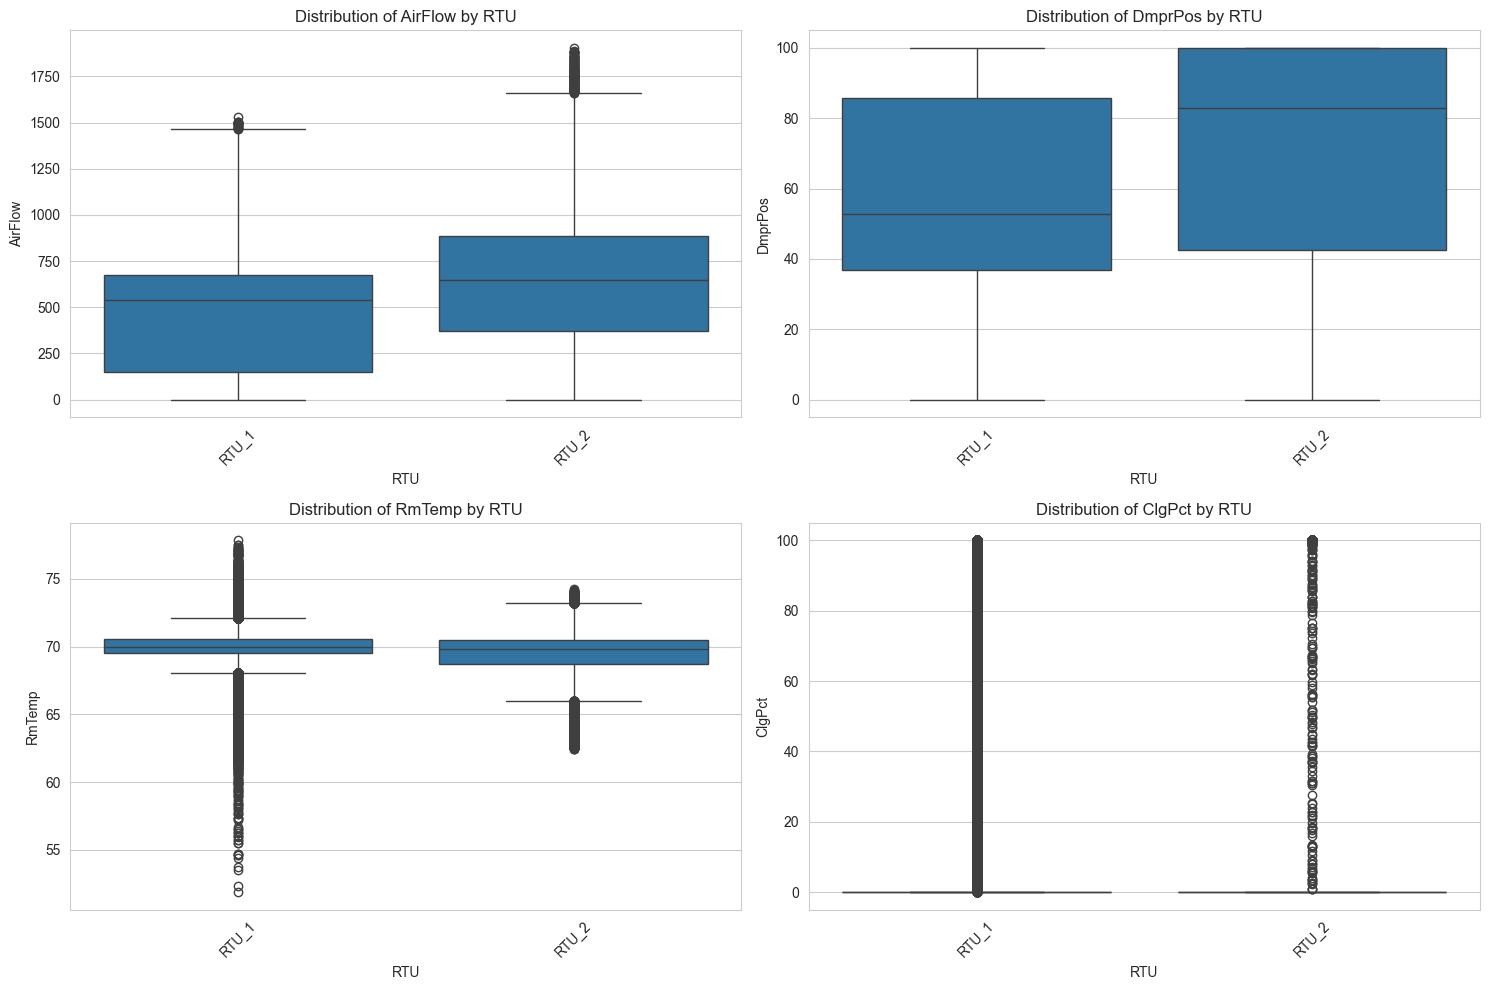

In [20]:
# =============================================
# 2. Boxplot Analysis for Continuous Variables
# =============================================
def plot_boxplots(df, metrics, figsize=(15, 10)):
    """Generate boxplots for specified metrics"""
    plt.figure(figsize=figsize)
    for i, metric in enumerate(metrics, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(data=df, x='RTU', y=metric)
        plt.title(f'Distribution of {metric} by RTU')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot for key metrics
plot_boxplots(vav_df, ['AirFlow', 'DmprPos', 'RmTemp', 'ClgPct'])


Number of data points with cooling - heating conflicts: 847
Terminal units with the most severe cooling - heating conflicts:


time                                             ClgPct  \
             count                 min                 max       mean   
RTU   VAV_ID                                                            
RTU_1 KK       581 2025-01-27 17:45:00 2025-03-19 13:45:00  37.638279   
      LL       266 2025-02-01 00:30:00 2025-03-19 00:45:00  47.882829   

                 HtgPct     RmTemp  
                   mean       mean  
RTU   VAV_ID                        
RTU_1 KK      58.177177  72.216037  
      LL      28.945714  69.959793

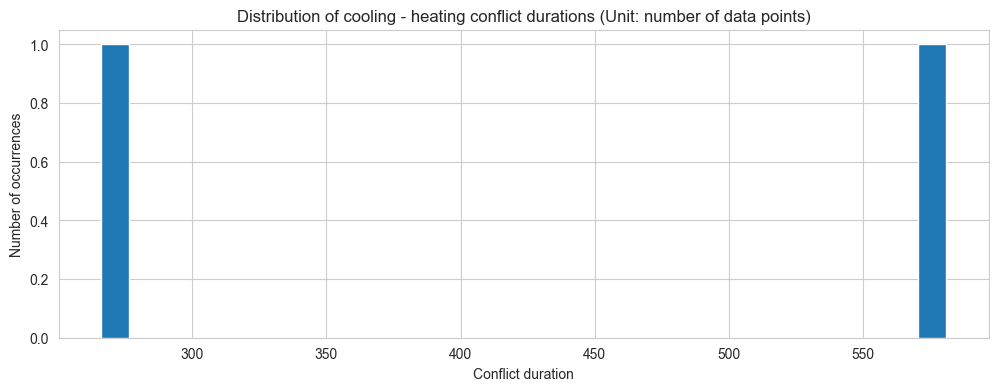

Anomaly statistics for RTU_1:
- Number of abnormal air flow occurrences: 4.0
- Abnormal damper positions: 0.0
- Average number of anomalies per terminal: 0.8
The most unstable terminals in RTU_2:


,RmTemp,AirFlow,total_outliers
VAV_ID,,,
F,0.352636,75.575888,4818
G,0.689352,34.877547,4818
I,0.938676,129.226133,4818
EE,0.594332,199.692638,4816
JJ,1.630243,185.997437,4816


In [23]:
# Check for simultaneous cooling and heating
conflict = vav_df[(vav_df['ClgPct'] > 20) & (vav_df['HtgPct'] > 20)]
print(f"Number of data points with cooling - heating conflicts: {len(conflict)}")

# Extract detailed conflict information
conflict_details = vav_df[
    (vav_df['ClgPct'] > 20) & 
    (vav_df['HtgPct'] > 20)
].groupby(['RTU', 'VAV_ID']).agg({
    'time': ['count', 'min', 'max'],
    'ClgPct': 'mean',
    'HtgPct': 'mean',
    'RmTemp': 'mean'
}).sort_values(('time', 'count'), ascending=False)

print("Terminal units with the most severe cooling - heating conflicts:")
display(conflict_details.head(10))

# Visualize the distribution of conflict periods
plt.figure(figsize=(12, 4))
conflict_details[('time', 'count')].hist(bins=30)
plt.title('Distribution of cooling - heating conflict durations (Unit: number of data points)')
plt.xlabel('Conflict duration')
plt.ylabel('Number of occurrences')
plt.show()

rtu1_issues = vav_df[vav_df['RTU'] == 'RTU_1'].agg({
    'AirFlow_outlier': 'sum',
    'DmprPos_outlier': 'sum',
    'total_outliers': 'mean'
})
print("Anomaly statistics for RTU_1:")
print(f"- Number of abnormal air flow occurrences: {rtu1_issues['AirFlow_outlier']}")
print(f"- Abnormal damper positions: {rtu1_issues['DmprPos_outlier']}")
print(f"- Average number of anomalies per terminal: {rtu1_issues['total_outliers']:.1f}")

# Identify the most unstable VAV terminals
rtu2_vav_stats = vav_df[vav_df['RTU'] == 'RTU_2'].groupby('VAV_ID').agg({
    'RmTemp': 'std',
    'AirFlow': 'std',
    'total_outliers': 'sum'
}).nlargest(5, 'total_outliers')

print("The most unstable terminals in RTU_2:")
display(rtu2_vav_stats)


3σ Outlier Counts per VAV:


,AirFlow_3sigma_outlier,RmTemp_3sigma_outlier,DschAirTemp_3sigma_outlier,DmprPos_3sigma_outlier
VAV_ID,,,,
A,0,59,0,0
AA,0,0,0,0
B,0,151,0,0
BB,0,0,0,0
C,0,0,0,0


Summary statistics of outliers:
       AirFlow_3sigma_outlier  RmTemp_3sigma_outlier  \
count               47.000000              47.000000   
mean                14.723404              57.872340   
std                 97.693554             105.084359   
min                  0.000000               0.000000   
25%                  0.000000               0.000000   
50%                  0.000000               0.000000   
75%                  0.000000              55.000000   
max                670.000000             409.000000   

       DschAirTemp_3sigma_outlier  DmprPos_3sigma_outlier  
count                   47.000000                    47.0  
mean                    34.531915                     0.0  
std                    158.929278                     0.0  
min                      0.000000                     0.0  
25%                      0.000000                     0.0  
50%                      0.000000                     0.0  
75%                      0.000000          

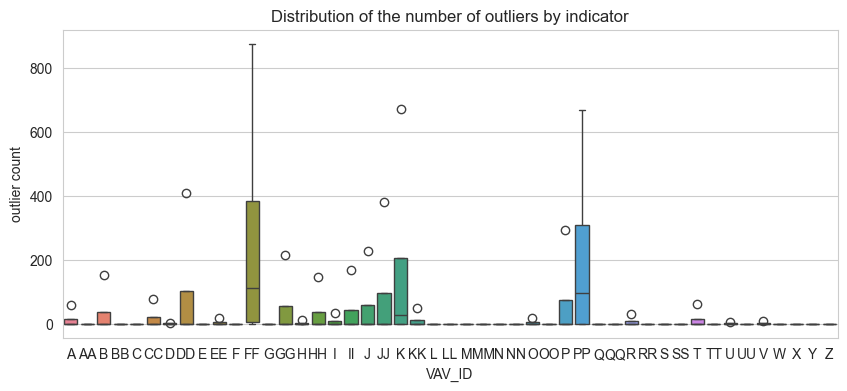

In [26]:
# =============================================
# 3. Outlier Detection (3σ Method)
# =============================================
def detect_3sigma_outliers(df, metrics):
    """Flag outliers beyond 3 standard deviations"""
    df = df.copy()
    for metric in metrics:
        if metric in df.columns:
            z_scores = np.abs(stats.zscore(df[metric].dropna()))
            df[f'{metric}_3sigma_outlier'] = z_scores > 3
    return df

# Apply to terminal units
vav_df = detect_3sigma_outliers(vav_df, 
                               ['AirFlow', 'RmTemp', 'DschAirTemp', 'DmprPos'])

# Count outliers per VAV
outlier_counts = vav_df.filter(like='_3sigma_outlier').groupby(vav_df['VAV_ID']).sum()
print("\n3σ Outlier Counts per VAV:")
display(outlier_counts.head())
# View Typical Statistics
print("Summary statistics of outliers:")
print(outlier_counts.describe())

# Visualize outlier distribution
plt.figure(figsize=(10,4))
sns.boxplot(data=outlier_counts.T)
plt.title("Distribution of the number of outliers by indicator")
plt.ylabel("outlier count")
plt.show()


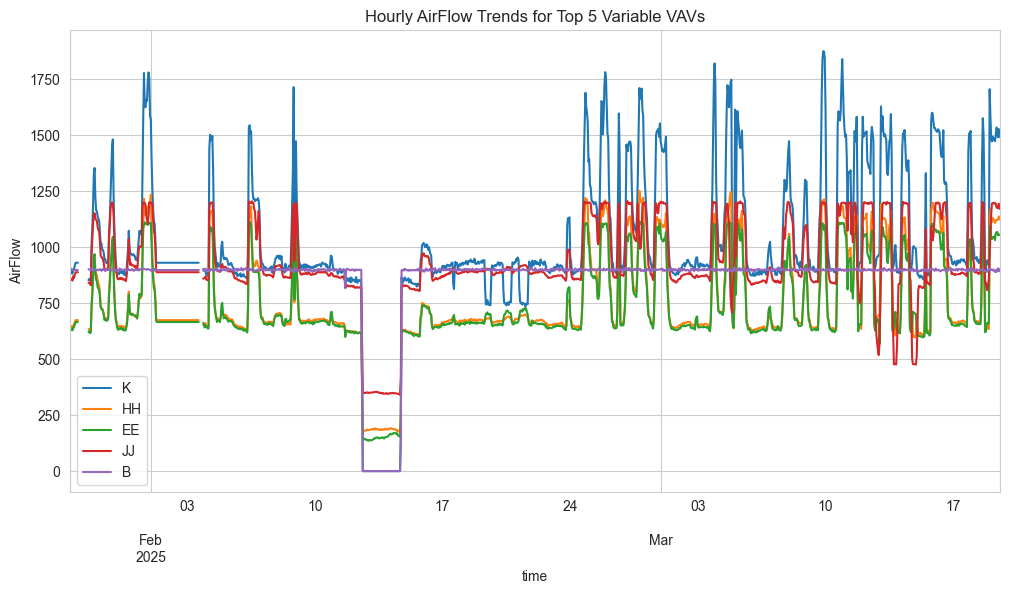

In [27]:
# =============================================
# 4. Temporal Trend Analysis
# =============================================
def plot_temporal_trends(df, metric, time_freq='h', top_n=5):
    """Plot temporal trends for metrics"""
    # Resample by time frequency
    temp_df = df.set_index('time').groupby('VAV_ID')[metric].resample(time_freq).mean()
    
    # Find top N units with highest variability
    most_variable = temp_df.groupby('VAV_ID').std().nlargest(top_n).index
    
    plt.figure(figsize=(12, 6))
    for unit in most_variable:
        temp_df.loc[unit].plot(label=unit)
    plt.title(f'Hourly {metric} Trends for Top {top_n} Variable VAVs')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

# Plot AirFlow trends
plot_temporal_trends(vav_df, 'AirFlow')

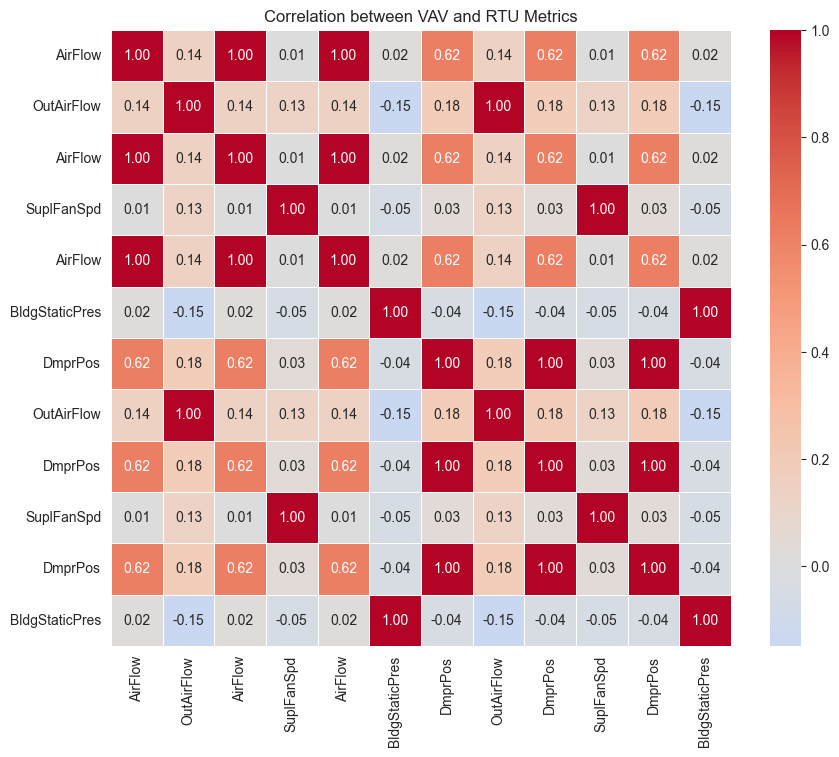

Successfully merged VAV and RTU data
Merged columns: ['VAV_ID', 'RTU_ID', 'time', 'AirFlow', 'Air_Flow_Diff', 'ClgPct_x', 'DmprPos', 'DschAirTemp', 'EffAirflowSp', 'EffOcc', 'EffSp', 'HtgPct_x', 'OccClgSp', 'OccCmd_x', 'OccHtgSp', 'RmSp', 'RmTemp_x', 'Room_Temperature_Diff', 'SaTemp', 'StbyClgSp', 'StbyHtgSp', 'UnoccClgSp_x', 'UnoccHtgSp_x', 'VAV_Temperature_Diff', 'oppMode_x', 'RmCo2', 'SuplFanCmd', 'SuplFanState', 'AirflowSpRht', 'SaTmp', 'Cooling_Stg_Cmd', 'Heating_Stg_Cmd', 'AirFlow_outlier', 'RmTemp_outlier_x', 'DschAirTemp_outlier', 'ClgPct_outlier_x', 'HtgPct_outlier_x', 'DmprPos_outlier', 'RmCo2_outlier', 'total_outliers', 'AirFlow_3sigma_outlier', 'RmTemp_3sigma_outlier', 'DschAirTemp_3sigma_outlier', 'DmprPos_3sigma_outlier', 'BldgStaticPres', 'BldgStaticPresSp', 'ClgPct_y', 'ClgStgCmd01', 'ClgStgCmd02', 'EconEna', 'EconEnaSp', 'EffRmSp', 'EffSuplAirTempSp', 'ExhAirDmprFbk', 'ExhFanSpd', 'ExhFanStatus', 'FltAlm', 'HtgAlm', 'HtgPct_y', 'HtgStgCmd01', 'HtgStgCmd02', 'OccCmd_y',

In [14]:
# =============================================
# 5. Corrected Comparative Analysis with RTU Data
# =============================================
def compare_with_rtu(vav_df, rtu_df):
    """Compare terminal unit metrics with parent RTU metrics"""
    # First ensure we have the correct merge keys
    # VAV data uses 'RTU' column (from your cleaned data structure)
    # RTU data uses 'RTU_ID' column
    
    # Prepare dataframes with consistent column names
    vav_prepared = vav_df.rename(columns={'RTU': 'RTU_ID'}).sort_values('time')
    rtu_prepared = rtu_df.sort_values('time')
    
    # Merge VAV data with RTU data on nearest timestamp
    try:
        merged = pd.merge_asof(
            vav_prepared,
            rtu_prepared,
            on='time',
            by='RTU_ID',
            direction='nearest',
            tolerance=pd.Timedelta('15min'))
        
        # Select available metrics for correlation
        available_metrics = []
        potential_metrics = {
            'vav': ['AirFlow', 'DmprPos', 'RmTemp'],
            'rtu': ['OutAirFlow', 'SuplFanSpd', 'BldgStaticPres']
        }
        
        # Check which columns exist in merged data
        for vav_metric in potential_metrics['vav']:
            for rtu_metric in potential_metrics['rtu']:
                if vav_metric in merged.columns and rtu_metric in merged.columns:
                    available_metrics.extend([vav_metric, rtu_metric])
        
        if len(available_metrics) >= 2:
            corr_matrix = merged[available_metrics].corr()
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                        fmt=".2f", linewidths=.5)
            plt.title('Correlation between VAV and RTU Metrics')
            plt.show()
        else:
            print("Insufficient overlapping metrics for correlation analysis")
            
        return merged
        
    except Exception as e:
        print(f"Merge failed: {str(e)}")
        return pd.DataFrame()

# Execute comparison (if RTU data available)
if not rtu_df.empty:
    merged_data = compare_with_rtu(vav_df, rtu_df)
    if not merged_data.empty:
        print("Successfully merged VAV and RTU data")
        print(f"Merged columns: {list(merged_data.columns)}")
    else:
        print("No data was merged")
else:
    print("RTU dataframe is empty - skipping comparison")

In [28]:
# First install the required package if missing
try:
    import openpyxl
except ImportError:
    print("Installing openpyxl...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    import openpyxl

# =============================================
# 6. Enhanced Save Analysis Results
# =============================================
def save_analysis_results(vav_stats, outlier_counts, merged_data=None, folder_path='../../outputs/HVAC_NewData_Analysis_Results'):
    """Save analysis results with error handling and path creation"""
    import os
    from datetime import datetime
    
    try:
        # Create directory if it doesn't exist
        os.makedirs(folder_path, exist_ok=True)
        
        # Generate timestamped filename
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{folder_path}/1.basic_statistical_analysis_{timestamp}.xlsx"
        
        # Save to Excel with multiple sheets
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            vav_stats.to_excel(writer, sheet_name='VAV_Statistics')
            outlier_counts.to_excel(writer, sheet_name='Outlier_Counts')
            
            if merged_data is not None and not merged_data.empty:
                # Calculate and save correlations if RTU data exists
                corr_matrix = merged_data.select_dtypes(include=['number']).corr()
                corr_matrix.to_excel(writer, sheet_name='RTU_Correlations')
                
                # Save sample merged data
                merged_data.head(100).to_excel(writer, sheet_name='Merged_Sample')
        
        print(f"Analysis successfully saved to: {filename}")
        return True
    
    except Exception as e:
        print(f"Error saving results: {str(e)}")
        return False

# Usage
save_success = save_analysis_results(
    vav_stats=vav_stats,
    outlier_counts=outlier_counts,
    merged_data=merged_data if not rtu_df.empty else None
)

if save_success:
    print("Basic statistical analysis completed and saved to Excel.")
else:
    print("Analysis completed but saving failed - see error above.")

Analysis successfully saved to: ../../outputs/HVAC_NewData_Analysis_Results/1.basic_statistical_analysis_20250407_144514.xlsx
Basic statistical analysis completed and saved to Excel.
